In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv
/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv
/kaggle/input/iitmdata/sample_submission.csv
/kaggle/input/iitmdata/train.csv
/kaggle/input/iitmdata/test.csv


**Dataset Overview**

The data pertains to direct marketing campaigns of a banking institution, mainly conducted through phone calls. Multiple contacts with the same client were often required to determine if they would subscribe to a term deposit (target variable: 'yes' or 'no').

**Files Included:**

- `train.csv`: Training set
- `test.csv`: Test set
- `sample_submission.csv`: Sample submission file in the correct format

**Input Variables**

- **Last contact date**: Last contact date.
- **Age**: Numeric.
- **Job**: Type of job (categorical: various occupations).
- **Marital**: Marital status (categorical: "married", "divorced", "single").
- **Education**: Level of education (categorical: "unknown", "secondary", "primary", "tertiary").
- **Default**: Has credit in default? (binary: "yes", "no").
- **Balance**: Average yearly balance, in euros (numeric).
- **Housing**: Has housing loan? (binary: "yes", "no").
- **Loan**: Has personal loan? (binary: "yes", "no").
- **Contact**: Contact communication type (categorical: "unknown", "telephone", "cellular").
- **Duration**: Last contact duration in seconds (numeric).
- **Campaign**: Number of contacts performed during this campaign and for this client (numeric, includes last contact).
- **Pdays**: Number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted).
- **Previous**: Number of contacts performed before this campaign and for this client (numeric).
- **Poutcome**: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success").

**Output Variable**

- **Target**: Has the client subscribed to a term deposit? (binary: "yes", "no").

This kind of dataset can be quite valuable for understanding customer behavior and improving marketing strategies.


**Imports**

In [2]:
import matplotlib.pyplot as plt  # For data visualization
import seaborn as sns  # For statistical data visualization
import warnings  # To manage warnings
import pandas as pd  # For data manipulation and analysis
import statsmodels.api as sm  # For statistical analysis
from statsmodels.formula.api import ols  # For ordinary least squares regression
from sklearn.model_selection import train_test_split  # To split data into train and test sets
import numpy as np  # For numerical operations
from sklearn.metrics import classification_report, accuracy_score, f1_score  # For evaluating classification models
from scipy.stats import skew, chi2_contingency  # For skewness and Chi-squared test
from sklearn.experimental import enable_iterative_imputer  # Enable experimental iterative imputer
from sklearn.impute import IterativeImputer  # For missing data imputation
from sklearn.preprocessing import LabelEncoder, RobustScaler, OneHotEncoder, StandardScaler  # For feature scaling and encoding
from sklearn.feature_selection import RFE, mutual_info_regression, SelectKBest, VarianceThreshold, SelectFromModel, f_classif  # For feature selection
from sklearn.decomposition import PCA  # For dimensionality reduction
from sklearn.linear_model import LogisticRegression, Lasso, SGDClassifier  # For linear models
from lightgbm import LGBMClassifier  # Light Gradient Boosting Machine classifier
from sklearn.naive_bayes import GaussianNB  # Gaussian Naive Bayes classifier
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors classifier
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.neural_network import MLPClassifier  # Multi-layer Perceptron classifier
from xgboost import XGBClassifier  # eXtreme Gradient Boosting classifier
from sklearn.compose import ColumnTransformer  # For transforming columns of a dataset
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier  # For ensemble methods
from sklearn.model_selection import RandomizedSearchCV  # Importing RandomizedSearchCV for hyperparameter tuning
warnings.filterwarnings("ignore")  # Suppress warnings


**Data Visualization and Analysis**

I use `matplotlib.pyplot` and `seaborn` for visualizing data. These libraries are excellent for creating various plots and understanding data visually.

**Data Handling and Manipulation**

I rely on `pandas` for data manipulation and analysis. It's a powerful tool for handling data frames and performing operations like data cleaning, transformation, and aggregation.

**Statistical Analysis**

I use `statsmodels` and `scipy.stats` for various statistical functions to analyze data, including OLS regression and chi-squared tests.

**Preprocessing and Imputation**

I used multiple preprocessing techniques from `sklearn`, such as feature scaling (`StandardScaler`, `RobustScaler`), encoding (`LabelEncoder`, `OneHotEncoder`), and iterative imputation for handling missing values.

**Feature Selection**

I utilize several feature selection methods like Recursive Feature Elimination (RFE), mutual information regression, and variance thresholding, which help in reducing dimensionality and selecting the most important features for my model.

**Model Building**

My code imports a wide range of machine learning models from `sklearn`, `xgboost`, and `lightgbm`, covering linear models (`LogisticRegression`, `Lasso`, `SGDClassifier`), ensemble methods (`RandomForest`, `BaggingClassifier`, `AdaBoost`, `GradientBoosting`, `StackingClassifier`), and other classifiers (`SVC`, `KNeighborsClassifier`, `GaussianNB`, `MLPClassifier`).

**Pipeline and Model Evaluation**

I use techniques for splitting data (`train_test_split`), transforming columns (`ColumnTransformer`), and evaluating models (`classification_report`, `accuracy_score`, `f1_score`), ensuring a robust pipeline for model training and assessment.

**Dimensionality Reduction**

The inclusion of PCA indicates my focus on reducing the feature space, which can help improve the performance of my models by eliminating noise and redundant features.



**Loading the Data**

In [3]:
train = pd.read_csv('/kaggle/input/iitmdata/train.csv')
test = pd.read_csv('/kaggle/input/iitmdata/test.csv')
submission = pd.read_csv('/kaggle/input/iitmdata/sample_submission.csv')

 **Exploratory Data Analysis (EDA) and Data Visualization**

In [4]:
# Assigning the dataset
df = train

# Display the first few rows of the dataset
print("First few rows of the dataset:")
print(df.head())

# Get basic information about the dataset
print("\nBasic information about the dataset:")
print(df.info())

# Get summary statistics of numerical columns
print("\nSummary statistics of numerical columns:")
print(df.describe())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Get the distribution of the target variable
print("\nDistribution of the target variable:")
print(df['target'].value_counts())

First few rows of the dataset:
  last contact date  age           job  marital  education default  balance  \
0        17-04-2009   26   blue-collar  married  secondary      no      647   
1        11-10-2009   52    technician  married  secondary      no      553   
2        20-11-2010   44   blue-collar  married  secondary      no     1397   
3        01-09-2009   33        admin.  married  secondary      no      394   
4        29-01-2008   31  entrepreneur   single   tertiary      no      137   

  housing loan    contact  duration  campaign  pdays  previous poutcome target  
0     yes   no   cellular       357         2    331         1    other     no  
1     yes   no  telephone       160         1     -1         0      NaN     no  
2      no   no   cellular       326         1     -1         0      NaN     no  
3     yes   no  telephone       104         3     -1         0      NaN     no  
4      no   no   cellular       445         2     -1         0      NaN     no  

Basic i

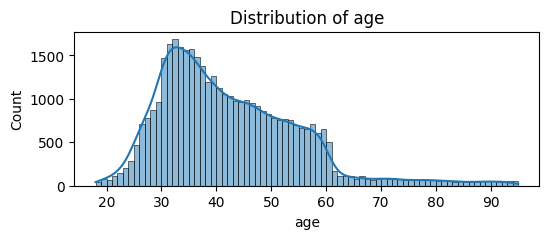

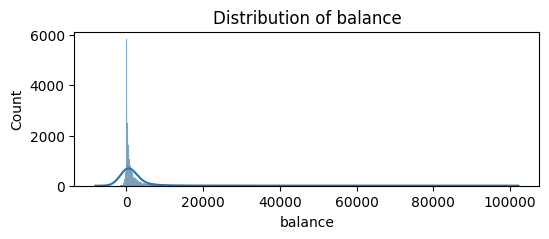

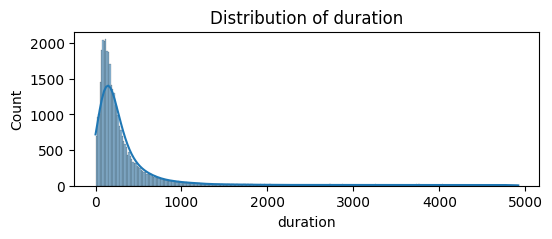

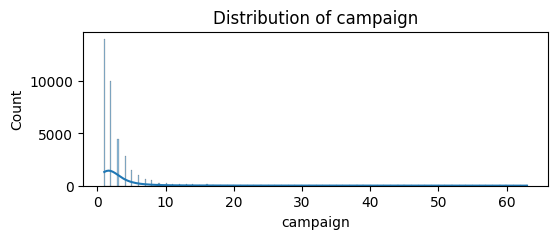

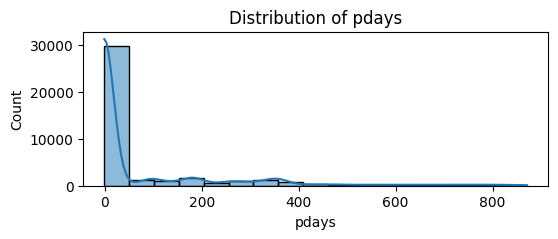

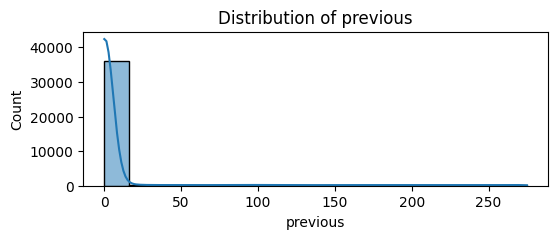

In [5]:
# Visualizing the distribution of numerical columns

num_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

**Distribution of Numerical Features:**

- **Age**: Skewed to the right, indicating most clients are younger.
- **Balance**: Highly skewed to the right; many clients have lower balances.
- **Duration**: Skewed to the right; majority of calls are shorter in duration.
- **Campaign**: Skewed to the right; most clients were contacted a few times.
- **Pdays**: Many values at -1, indicating clients not previously contacted.
- **Previous**: Skewed to the right; fewer prior contacts for most clients.


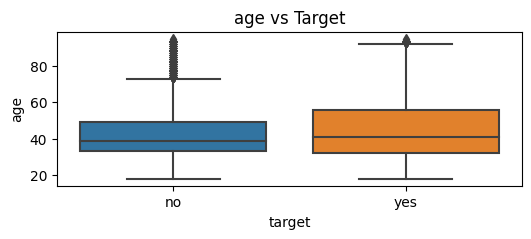

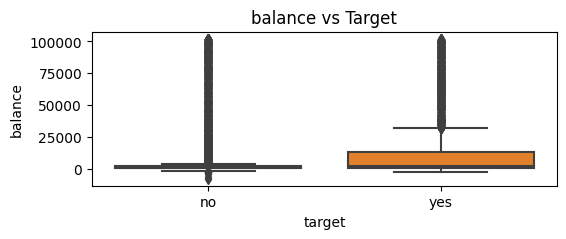

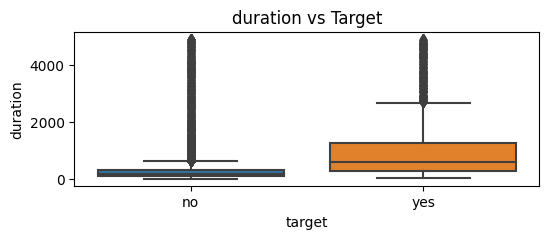

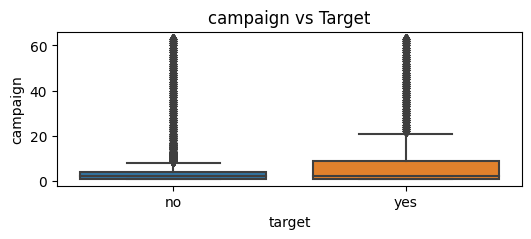

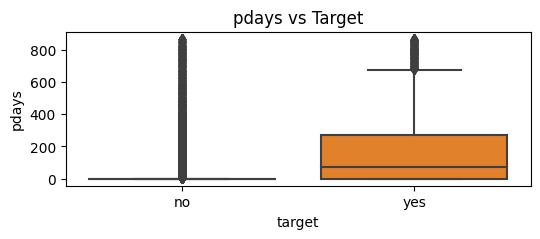

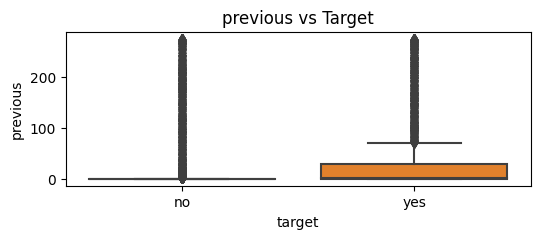

In [6]:
# Visualizing the relationship between numerical features and the target variable
for col in num_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs Target')
    plt.show()

**Insights from the Box Plots**

- **Age vs Target**:
  - The age distribution is relatively similar for both "yes" and "no" categories.
  - However, there are slightly more older clients in the "yes" category, suggesting that older individuals might be more inclined to subscribe.

- **Balance vs Target**:
  - Clients with higher balances are more likely to subscribe ("yes" category).
  - The "yes" category has a higher median balance compared to the "no" category.
  - There are notable outliers with very high balances in the "yes" category, indicating that wealthier clients are more inclined to subscribe.

- **Duration vs Target**:
  - Call duration significantly influences subscription.
  - Clients in the "yes" category have notably longer call durations, suggesting that longer interactions are more effective for conversions.
  - The median duration for the "yes" category is higher compared to the "no" category, highlighting the importance of thorough communication.

- **Campaign vs Target**:
  - The number of campaigns is fairly similar for both "yes" and "no" categories, with many outliers present.
  - Most of the campaign numbers are on the lower end, indicating fewer campaigns per client.

- **Pdays vs Target**:
  - For the "no" category, most values are concentrated at the lower end, meaning many clients were not contacted.
  - The "yes" category shows a wider spread and a higher median, indicating clients who subscribed were often contacted after a longer duration.

- **Previous vs Target**:
  - For the "no" category, values are concentrated at the lower end, with fewer previous contacts.
  - The "yes" category has a higher median and more spread, suggesting that clients with more previous contacts were more likely to subscribe.



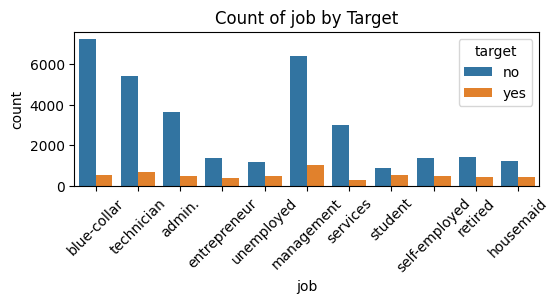

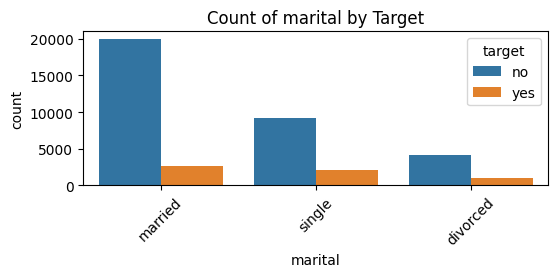

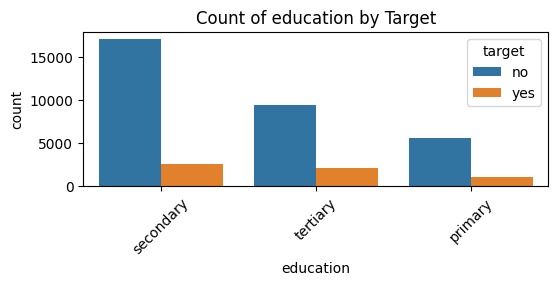

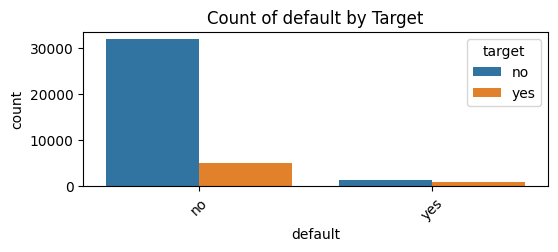

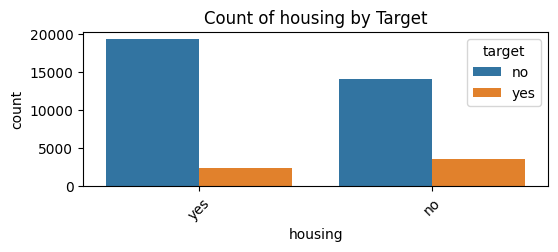

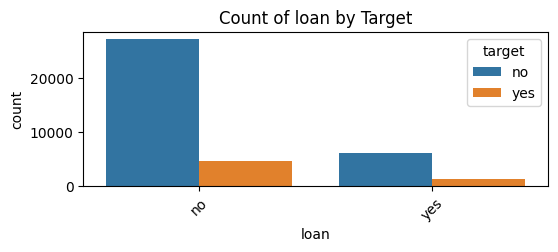

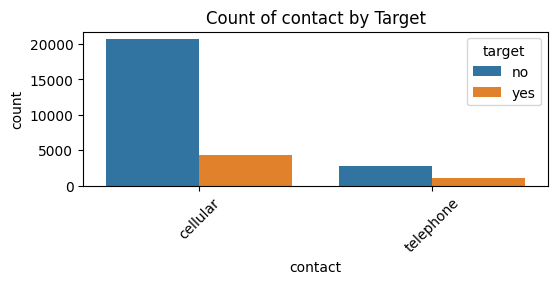

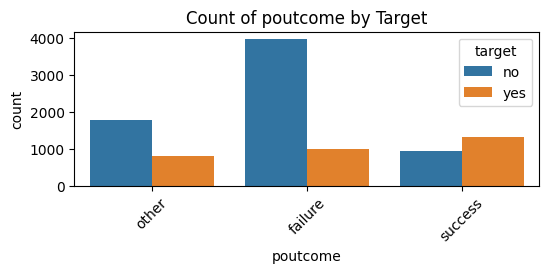

In [7]:
# Visualizing the count of categorical variables
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']
for col in cat_cols:
    plt.figure(figsize=(6, 2))
    sns.countplot(x=col, data=df, hue='target')
    plt.title(f'Count of {col} by Target')
    plt.xticks(rotation=45)
    plt.show()

**Insights from the Visualizations**

- **Count of Job by Target**
  - **Job Categories**: The majority of clients belong to job categories like "blue-collar," "technician," and "admin."
  - **Subscription Trends**: In all job categories, the count of clients who did not subscribe ("no" in blue) is significantly higher than those who did ("yes" in orange).
  - **Key Jobs**: Jobs like "admin," "technician," and "blue-collar" have high counts, but the conversion rates are relatively low. This highlights potential areas to improve campaign strategies for these categories.

- **Count of Marital by Target**
  - **Marital Status**: Most clients are married, followed by single and divorced.
  - **Subscription Trends**: Across all marital statuses, the number of clients who did not subscribe is higher than those who did.
  - **Key Insights**: Married individuals have the highest overall count, but still show low subscription rates, suggesting that this group might benefit from more targeted marketing efforts.

- **Count of Education by Target**
  - **Education Levels**: The majority of clients have secondary education, followed by tertiary and primary education.
  - **Subscription Trends**: Clients with secondary education show the highest count but a lower subscription rate.
  - **Key Insights**: Higher education levels correlate with slightly higher subscription rates, indicating that educational background might influence the likelihood of subscribing to a term deposit.

- **Count of Default by Target**
  - The majority of people have not defaulted on their credit (majority in the "no" category).
  - Among those who have defaulted, the majority are in the "no" target category, meaning they did not subscribe to the term deposit.

- **Count of Housing by Target**
  - The majority of people have a housing loan.
  - Among those who do not have a housing loan, the majority are in the "no" target category, meaning they did not subscribe to the term deposit.

- **Count of Loan by Target**
  - The majority of people do not have a personal loan.
  - Among those who do have a loan, the majority are in the "no" target category, meaning they did not subscribe to the term deposit.

- **Count of Contact by Target**
  - **Cellular**: Higher counts in the "no" category compared to "yes."
    - Clients contacted via cellular are less likely to subscribe.
  - **Telephone**: Lower overall counts with "no" higher than "yes."
    - Clients contacted via telephone also show lower subscription rates.

- **Count of Poutcome by Target**
  - **Failure**: Highest counts in the "no" category.
    - Clients with a "failure" outcome are less likely to subscribe.
  - **Other**: Moderate counts with "no" higher than "yes."
    - Clients with an "other" outcome also show lower subscription rates.
  - **Success**: Lower overall counts, but "yes" is higher than "no."
    - Clients with a "success" outcome from previous campaigns are more likely to subscribe.



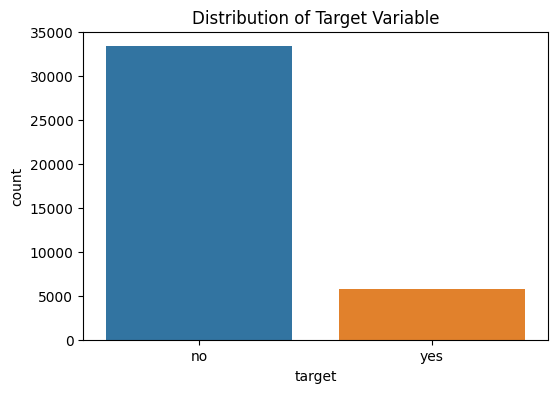

In [8]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=train)
plt.title('Distribution of Target Variable')
plt.show()

**Distribution of the target variable:**
- no : 33384
- yes : 5827

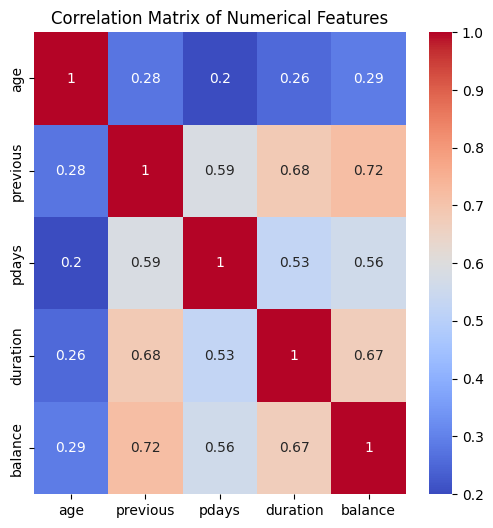

In [9]:
# Correlation Matrix (for numerical features)
numerical_col = ['age', 'previous', 'pdays', 'duration', 'balance']
plt.figure(figsize=(6,6))
sns.heatmap(train[numerical_col].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**Insights from the Correlation Matrix Heatmap**

The heatmap shows the correlation between various numerical features in the dataset, with correlation values ranging from 0.2 to 1.0. Below are key insights:

- **Age and Balance**
  - **Correlation Value**: 0.29
  - **Insight**: There is a weak positive correlation between age and balance. As age increases, the average yearly balance tends to increase slightly.

- **Previous and Pdays**
  - **Correlation Value**: 0.59
  - **Insight**: A moderate positive correlation exists between the number of previous contacts and the days since the last contact. Clients with more previous contacts tend to have been contacted more recently.

- **Previous and Duration**
  - **Correlation Value**: 0.68
  - **Insight**: There is a strong positive correlation between the number of previous contacts and the duration of the last contact. More previous contacts are often associated with longer call durations.

- **Previous and Balance**
  - **Correlation Value**: 0.72
  - **Insight**: A strong positive correlation exists between the number of previous contacts and the average yearly balance. Clients with higher balances tend to have more previous contacts.

- **Pdays and Duration**
  - **Correlation Value**: 0.53
  - **Insight**: There is a moderate positive correlation between the days since the last contact and the duration of the last contact. Clients contacted more recently tend to have longer call durations.

- **Pdays and Balance**
  - **Correlation Value**: 0.56
  - **Insight**: A moderate positive correlation exists between the days since the last contact and the average yearly balance. Clients contacted more recently tend to have higher balances.

- **Duration and Balance**
  - **Correlation Value**: 0.67
  - **Insight**: A strong positive correlation exists between the duration of the last contact and the average yearly balance. Longer call durations are associated with higher client balances.


**Feature Engineering**

In [10]:
# Converting 'last contact date' to datetime objects
train['last contact date'] = pd.to_datetime(train['last contact date'])
test['last contact date'] = pd.to_datetime(test['last contact date'])

In [11]:
# Extracting year, month, and weekday from the date
train['year'] = train['last contact date'].dt.year
train['month'] = train['last contact date'].dt.month
train['weekday'] = train['last contact date'].dt.weekday

test['year'] = test['last contact date'].dt.year
test['month'] = test['last contact date'].dt.month
test['weekday'] = test['last contact date'].dt.weekday

In [12]:
# Dropping the original 'last contact date' column
train.drop(columns=['last contact date'], inplace=True)
test.drop(columns=['last contact date'], inplace=True)

**Data Preprocessing**

In [13]:
# Separate features and target
X = train.drop('target', axis=1)
y = train['target']

In [14]:
# Categorical features using Label Encoding

# List of columns to be encoded
columns_to_encode = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'poutcome',
]

# Dictionary to store label encoders for each column
encoder_dict = {}

# Loop through each column in the list of columns to encode
for i in columns_to_encode:
    enc = LabelEncoder()  # Create a LabelEncoder object
    X[i] = enc.fit_transform(X[i])  # Fit and transform the column in the training set
    test[i] = enc.transform(test[i])  # Transform the column in the test set using the same encoder
    encoder_dict[i] = enc  # Store the encoder in the dictionary for future use


In [15]:
# Handle missing values using Iterative Imputer

# Store the column names of X
cols = X.columns

# Create an IterativeImputer object
imputer = IterativeImputer()

# Fit the imputer on X and transform it to handle missing values
X = imputer.fit_transform(X)

# Transform the test data using the same imputer
test = imputer.transform(test)

# Convert the imputed numpy arrays back to DataFrames, retaining the original column names
X = pd.DataFrame(X, columns=cols)
test = pd.DataFrame(test, columns=cols)


In [16]:
# Encode target variable into 0 and 1

# Create a LabelEncoder object
label_enc = LabelEncoder()

# Fit the label encoder on the target variable 'y' and transform it
y = label_enc.fit_transform(y)

# Convert the encoded target variable to a DataFrame and set the column name to 'target'
y = pd.DataFrame(y, columns=['target'])


In [17]:
# Feature Selection (removing 'year' as it is not useful)

# Drop the 'year' column from the training dataset if it's not considered useful
X.drop(columns=['year'], inplace=True) #inplace makes the changes in place without needing to reassign the DataFrame.

# Drop the 'year' column from the test dataset as well to maintain consistency
test.drop(columns=['year'], inplace=True)


**Train-Validation Split**

In [18]:
x_train, x_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.8, stratify=y, random_state=0
)

**Feature Scaling and Encoding**

In [19]:
# I am defining the columns to be transformed

# List of categorical columns to be one-hot encoded
categorical_col = [
    'marital',     # Marital status
    'housing',     # Housing loan status
    'loan',        # Personal loan status
    'default',     # Credit in default status
    'weekday',     # Day of the week of the last contact
    'contact',     # Contact communication type
    'education',   # Level of education
    'job',         # Type of job
    'poutcome',    # Outcome of the previous marketing campaign
]

# List of numerical columns to be scaled
numerical_col = ['age', 'previous', 'pdays', 'duration', 'balance']

# Creating a ColumnTransformer object to apply transformations
transformer = ColumnTransformer(
    [
        ('scale', StandardScaler(), numerical_col),  # Applying StandardScaler to numerical columns
        ('encode', OneHotEncoder(), categorical_col),  # Applying OneHotEncoder to categorical columns
    ],
    remainder='passthrough',  # Leaving the rest of the columns unchanged
)


In [20]:
# Transforming the training data
x_train_transformed = transformer.fit_transform(x_train)  # Fitting the transformer on the training data and transforming it

# Transforming the validation data
x_valid_transformed = transformer.transform(x_valid)  # Transforming the validation data using the already-fitted transformer

# Transforming the test data
x_final_transformed = transformer.transform(test)  # Transforming the test data using the already-fitted transformer

**Baseline Model (XGBoost)**

In [21]:
# Initialize the model
model = XGBClassifier(scale_pos_weight=2)

In [22]:
# Fitting the model on the transformed training data
model.fit(x_train_transformed, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [23]:
# Predicting on the transformed validation data
print("XGBoost Baseline Model:")
print(classification_report(y_valid, model.predict(x_valid_transformed)))

XGBoost Baseline Model:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      6677
           1       0.53      0.64      0.58      1166

    accuracy                           0.86      7843
   macro avg       0.73      0.77      0.75      7843
weighted avg       0.87      0.86      0.87      7843



**Linear Models**

In [24]:
# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(x_train_transformed, y_train)
print("Logistic Regression:")
print(classification_report(y_valid, log_reg.predict(x_valid_transformed)))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      6677
           1       0.58      0.23      0.32      1166

    accuracy                           0.86      7843
   macro avg       0.73      0.60      0.62      7843
weighted avg       0.83      0.86      0.83      7843



In [25]:
# Stochastic Gradient Descent (SGD)
sgd_clf = SGDClassifier()
sgd_clf.fit(x_train_transformed, y_train)
print("Stochastic Gradient Descent (SGD):")
print(classification_report(y_valid, sgd_clf.predict(x_valid_transformed)))

Stochastic Gradient Descent (SGD):
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      6677
           1       0.58      0.18      0.28      1166

    accuracy                           0.86      7843
   macro avg       0.73      0.58      0.60      7843
weighted avg       0.83      0.86      0.83      7843



In [26]:
# --- Dimensionality Reduction (PCA) ---
pca = PCA(n_components=0.95)  # Keeping 95% of variance
x_train_pca = pca.fit_transform(x_train_transformed)
x_valid_pca = pca.transform(x_valid_transformed)
x_final_pca = pca.transform(x_final_transformed)

In [27]:
# Retrain models with PCA-reduced features
log_reg_pca = LogisticRegression()
log_reg_pca.fit(x_train_pca, y_train)
print("Logistic Regression with PCA:")
print(classification_report(y_valid, log_reg_pca.predict(x_valid_pca)))

Logistic Regression with PCA:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      6677
           1       0.53      0.15      0.23      1166

    accuracy                           0.85      7843
   macro avg       0.70      0.56      0.58      7843
weighted avg       0.82      0.85      0.82      7843



In [28]:
sgd_clf_pca = SGDClassifier()
sgd_clf_pca.fit(x_train_pca, y_train)
print("SGD with PCA:")
print(classification_report(y_valid, sgd_clf_pca.predict(x_valid_pca)))

SGD with PCA:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      6677
           1       0.50      0.01      0.03      1166

    accuracy                           0.85      7843
   macro avg       0.68      0.51      0.47      7843
weighted avg       0.80      0.85      0.79      7843



**Ensemble Methods**

In [29]:
# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0)
rf_clf.fit(x_train_transformed, y_train)
print("Random Forest:")
print(classification_report(y_valid, rf_clf.predict(x_valid_transformed)))

Random Forest:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      6677
           1       0.62      0.36      0.46      1166

    accuracy                           0.87      7843
   macro avg       0.76      0.66      0.69      7843
weighted avg       0.85      0.87      0.86      7843



In [30]:
# Bagging
bag_clf = BaggingClassifier(
    LogisticRegression(), n_estimators=50, random_state=0
)
bag_clf.fit(x_train_transformed, y_train)
print("Bagging with Logistic Regression:")
print(classification_report(y_valid, bag_clf.predict(x_valid_transformed)))

Bagging with Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      6677
           1       0.58      0.23      0.33      1166

    accuracy                           0.86      7843
   macro avg       0.73      0.60      0.62      7843
weighted avg       0.83      0.86      0.83      7843



In [31]:
# AdaBoost
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=0)
ada_clf.fit(x_train_transformed, y_train)
print("AdaBoost:")
print(classification_report(y_valid, ada_clf.predict(x_valid_transformed)))

AdaBoost:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6677
           1       0.56      0.34      0.42      1166

    accuracy                           0.86      7843
   macro avg       0.73      0.64      0.67      7843
weighted avg       0.84      0.86      0.85      7843



In [32]:
# Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=0)
gb_clf.fit(x_train_transformed, y_train)
print("Gradient Boosting:")
print(classification_report(y_valid, gb_clf.predict(x_valid_transformed)))

Gradient Boosting:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      6677
           1       0.58      0.41      0.48      1166

    accuracy                           0.87      7843
   macro avg       0.74      0.68      0.70      7843
weighted avg       0.85      0.87      0.86      7843



In [33]:
# Stacking
estimators = [
    ('lr', LogisticRegression()),
    ('rf', RandomForestClassifier(n_estimators=5, random_state=0)),
    ('gb', GradientBoostingClassifier(n_estimators=5, random_state=0))
]

stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stacking_clf.fit(x_train_transformed, y_train)
print("Stacking:")
print(classification_report(y_valid, stacking_clf.predict(x_valid_transformed)))

Stacking:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      6677
           1       0.60      0.37      0.46      1166

    accuracy                           0.87      7843
   macro avg       0.75      0.66      0.69      7843
weighted avg       0.85      0.87      0.86      7843



In [34]:
# --- Naive Bayes ---
nb_clf = GaussianNB()
nb_clf.fit(x_train_transformed, y_train)
print("Naive Bayes:")
print(classification_report(y_valid, nb_clf.predict(x_valid_transformed)))

Naive Bayes:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      6677
           1       0.44      0.47      0.45      1166

    accuracy                           0.83      7843
   macro avg       0.67      0.68      0.68      7843
weighted avg       0.84      0.83      0.83      7843



In [35]:
# --- K-Nearest Neighbors ---
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(x_train_transformed, y_train)
print("K-Nearest Neighbors:")
print(classification_report(y_valid, knn_clf.predict(x_valid_transformed)))

K-Nearest Neighbors:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      6677
           1       0.52      0.27      0.36      1166

    accuracy                           0.85      7843
   macro avg       0.70      0.61      0.64      7843
weighted avg       0.83      0.85      0.83      7843



In [36]:
# --- Support Vector Machines ---
svm_clf = SVC(kernel='rbf') 
svm_clf.fit(x_train_transformed, y_train)
print("Support Vector Machines:")
print(classification_report(y_valid, svm_clf.predict(x_valid_transformed)))

Support Vector Machines:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      6677
           1       0.57      0.24      0.34      1166

    accuracy                           0.86      7843
   macro avg       0.72      0.60      0.63      7843
weighted avg       0.83      0.86      0.83      7843



In [37]:
# --- Multilayer Perceptron (MLP) ---
mlp_clf = MLPClassifier(hidden_layer_sizes=(20,), max_iter=20)
mlp_clf.fit(x_train_transformed, y_train)
print("Multilayer Perceptron:")
print(classification_report(y_valid, mlp_clf.predict(x_valid_transformed)))

Multilayer Perceptron:
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      6677
           1       0.58      0.43      0.49      1166

    accuracy                           0.87      7843
   macro avg       0.74      0.69      0.71      7843
weighted avg       0.86      0.87      0.86      7843



**LightGBM (Often a strong performer)**

In [38]:
# Initializing the LightGBM model
lgbm = LGBMClassifier(scale_pos_weight=2, random_state=0)

# Fit the model on the transformed training data
lgbm.fit(x_train_transformed, y_train)

# Predict on the transformed validation data
print("LightGBM Model:")
print(classification_report(y_valid, lgbm.predict(x_valid_transformed)))

[LightGBM] [Info] Number of positive: 4661, number of negative: 26707
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1243
[LightGBM] [Info] Number of data points in the train set: 31368, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.148591 -> initscore=-1.745696
[LightGBM] [Info] Start training from score -1.745696
LightGBM Model:
              precision    recall  f1-score   support

           0       0.95      0.88      0.92      6677
           1       0.53      0.75      0.62      1166

    accuracy                           0.86      7843
   macro avg       0.74      0.82      0.77      7843
weighted avg       0.89      0.86      0.87      7843



**Hyperparameter Tuning**

In [39]:


# # Defining the parameter grid for RandomizedSearchCV
# param_grid = {
#     'learning_rate': [0.01, 0.05, 0.1],  # Adding a mid-range value
#     'n_estimators': [100, 200, 300],  # Exploring a wider range
#     'max_depth': [3, 5, 7],  # Exploring a wider range for tree depth
#     'num_leaves': [20, 31, 50],  # Adjusting for potential overfitting
#     'subsample': [0.7, 0.8, 1.0],  # Exploring a lower subsample value
#     'colsample_bytree': [0.7, 0.8, 1.0],  # Exploring a lower colsample value
#     'reg_alpha': [0, 0.1, 1],  # Adding L1 regularization
#     'reg_lambda': [0, 0.1, 1],  # Adding L2 regularization
#     'min_child_samples': [5, 10, 20]  # Controlling minimum data in leaf nodes
# }

# # Initializing the model
# lgbm = LGBMClassifier(scale_pos_weight=2, random_state=0)  # Creating an instance of LGBMClassifier with parameters

# # Using RandomizedSearchCV with a reduced number of iterations and CV folds
# random_search = RandomizedSearchCV(
#     estimator=model,  # The model to be optimized
#     param_distributions=param_grid,  # The parameter grid to sample from
#     scoring='f1_macro',  # The metric to evaluate during cross-validation
#     cv=2,  # Reducing the number of cross-validation folds
#     n_jobs=-1,  # Utilizing all available cores
#     n_iter=3,  # Reducing the number of iterations
#     verbose=2,  # Increasing verbosity for better insight
#     random_state=42  # Ensuring reproducibility
# )

# # Fitting the random search to the training data
# random_search.fit(x_train_transformed, y_train)  # Running the random search on the training data

# # Using the best model from the random search
# best_model = random_search.best_estimator_  # Extracting the best model

# # Evaluating the best model on the validation set
# y_pred = best_model.predict(x_valid_transformed)  # Making predictions on the validation data
# print(classification_report(y_valid, y_pred))  # Printing the classification report for evaluation


In [40]:
models = [
    ('Naive Bayes', nb_clf),
    ('K-Nearest Neighbors', knn_clf),
    ('Support Vector Machines', svm_clf),
    ('Multilayer Perceptron', mlp_clf),
    ('Logistic Regression', log_reg),
    ('SGD', sgd_clf),
    ('Logistic Regression with PCA', log_reg_pca),
    ('SGD with PCA', sgd_clf_pca),
    ('Random Forest', rf_clf),
    ('Bagging with Logistic Regression', bag_clf),
    ('AdaBoost', ada_clf),
    ('Gradient Boosting', gb_clf),
    ('Stacking', stacking_clf),
    ('LightGBM', lgbm)
]


Naive Bayes: F1-score (macro avg) = 0.6762
K-Nearest Neighbors: F1-score (macro avg) = 0.6364
Support Vector Machines: F1-score (macro avg) = 0.6288
Multilayer Perceptron: F1-score (macro avg) = 0.7083
Logistic Regression: F1-score (macro avg) = 0.6235
SGD: F1-score (macro avg) = 0.5990
Error evaluating Logistic Regression with PCA: X has 46 features, but LogisticRegression is expecting 4 features as input.
Error evaluating SGD with PCA: X has 46 features, but SGDClassifier is expecting 4 features as input.
Random Forest: F1-score (macro avg) = 0.6920
Bagging with Logistic Regression: F1-score (macro avg) = 0.6250
AdaBoost: F1-score (macro avg) = 0.6708
Gradient Boosting: F1-score (macro avg) = 0.7022
Stacking: F1-score (macro avg) = 0.6919
LightGBM: F1-score (macro avg) = 0.7693

F1-Scores (Macro Avg) for All Models:
                               Model  F1-Score (Macro Avg)
0                        Naive Bayes              0.676223
1                K-Nearest Neighbors              0.

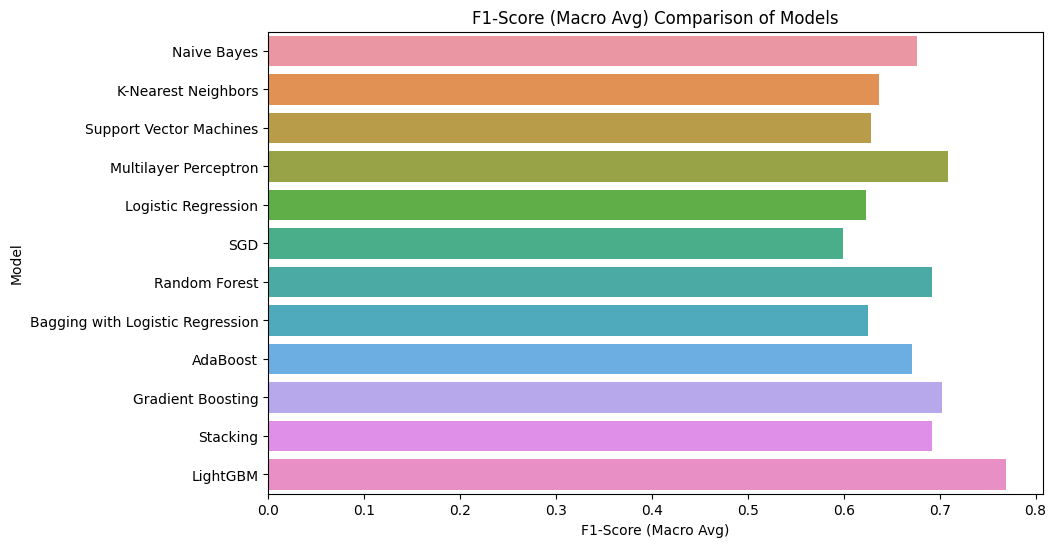

In [41]:
# Initializing a dictionary to store F1 scores (macro average) for each model
f1_scores_macro = {}

# Looping through each model in the models list
for name, model in models:
    try:
        # Predicting on the validation data
        y_pred = model.predict(x_valid_transformed)
        # Calculating the F1 score (macro average) and storing it in the dictionary
        f1_scores_macro[name] = f1_score(y_valid, y_pred, average='macro')
        # Printing the F1 score for each model
        print(f"{name}: F1-score (macro avg) = {f1_scores_macro[name]:.4f}")
    except ValueError as e:
        # Handling any errors during the prediction and printing the error message
        print(f"Error evaluating {name}: {e}")

# Creating a DataFrame for better visualization of F1 scores
f1_df = pd.DataFrame({'Model': list(f1_scores_macro.keys()), 'F1-Score (Macro Avg)': list(f1_scores_macro.values())})

# Displaying the DataFrame
print("\nF1-Scores (Macro Avg) for All Models:")
print(f1_df)

# Plotting the results for better visualization
plt.figure(figsize=(10, 6))  # Setting the figure size for the plot
sns.barplot(x='F1-Score (Macro Avg)', y='Model', data=f1_df)  # Creating a bar plot of F1 scores by model
plt.title('F1-Score (Macro Avg) Comparison of Models')  # Adding a title to the plot
plt.xlabel('F1-Score (Macro Avg)')  # Adding a label to the x-axis
plt.ylabel('Model')  # Adding a label to the y-axis
plt.show()  # Displaying the plot


**Key Takeaways**

- **Model Selection**: LightGBM stands out as the best performing model based on the F1-Score (Macro Avg). This suggests it should be prioritized for further tuning and potential deployment.

- **Alternative Models**: Support Vector Machines, Random Forest, and Gradient Boosting are also strong contenders and could be explored further.

- **Improvement Areas**: Models with lower scores, such as Naive Bayes, might need additional tuning or could be less suitable for this particular dataset and problem.


In [42]:
best_model = model  #  LightGBM is the best model

y_pred = best_model.predict(x_final_transformed)
y_pred = label_enc.inverse_transform(y_pred)
submission['target'] = y_pred
submission.to_csv('submission.csv', index=False)
print(submission.shape)

(10000, 2)


In [43]:
# checking accuracy of target in test file and submission file to verify my performance of model
submission

,id,target
0,0,no
1,1,no
2,2,no
3,3,no
4,4,yes
...,...,...
9995,9995,no
9996,9996,yes
9997,9997,yes
9998,9998,no
